In [12]:
#!pip install umap-learn

In [13]:
%matplotlib inline

References: 
   
   - https://umap-learn.readthedocs.io/en/latest/transform.html
   - https://plotly.com/python/t-sne-and-umap-projections/
   - https://pair-code.github.io/understanding-umap/

## UMAP ne prend pas en compte les labels 
# UMAP on the MNIST Digits dataset

A simple example demonstrating how to use UMAP on a larger dataset such as MNIST. 
We first pull the MNIST dataset and then use UMAP to reduce it to only 2-dimensions for easy visualisation.

Note that UMAP manages to both group: 
 - the individual digit classes, 
 - but also to retain the overall global structure among the different digit classes 
 
keeping 1 far from 0, and grouping triplets of 3,5,8 and 4,7,9 which can blend into one another in some cases.

In [54]:
import umap
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE, MDS
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [55]:
sns.set_theme(context="paper", style="white")
%time mnist = fetch_openml("mnist_784", version=1) #,return_X_y=True)

CPU times: user 1.72 s, sys: 317 ms, total: 2.04 s
Wall time: 2.07 s


crée un objet UMAP avec une graine fixée pour rendre l’embedding aussi reproductible que possible.

In [67]:
import umap
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    metric="euclidean",
    random_state=42,   # pour la reproductibilité
)

Sans graine, chaque appel à fit ou fit_transform donnera un embedding légèrement différent.

In [ ]:
subset_size = 10000

%time embedding1 = reducer.fit_transform(mnist.data[:subset_size])

CPU times: user 1.39 s, sys: 1.84 s, total: 3.22 s
Wall time: 863 ms


In [74]:
color = mnist.target[:subset_size].astype(int)
# dont show label randomly for X% of points
chosen_idx = np.random.choice(subset_size, replace = False, size = int(0.7*subset_size))
color[chosen_idx] = 10

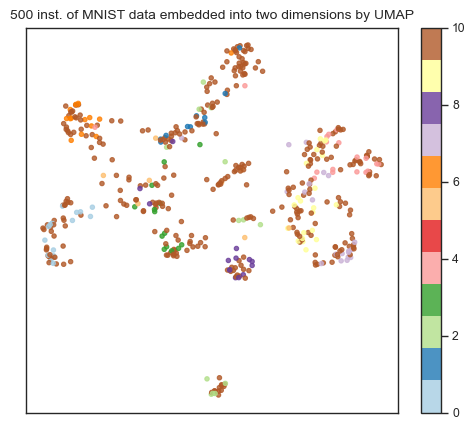

In [75]:
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(embedding1[:, 0], embedding1[:, 1], c=color, cmap = "Paired", s=10, alpha=0.8)
plt.setp(ax, xticks=[], yticks=[])
plt.title(f"{len(embedding1)} inst. of MNIST data embedded into two dimensions by UMAP", fontsize=10)
plt.colorbar()
plt.show()

## Exercice 

sur le modèle du notebook avec Selftraining / Labelpropagation

- entrainez un modèle de K plus proches voisins sur la projection faite par UMAP
- appliquer le selftraining ou une propagation de labels

## Version complète MNIST

In [71]:
%time embedding2 = reducer.fit_transform(mnist.data)

CPU times: user 1min 1s, sys: 4.16 s, total: 1min 5s
Wall time: 33.3 s


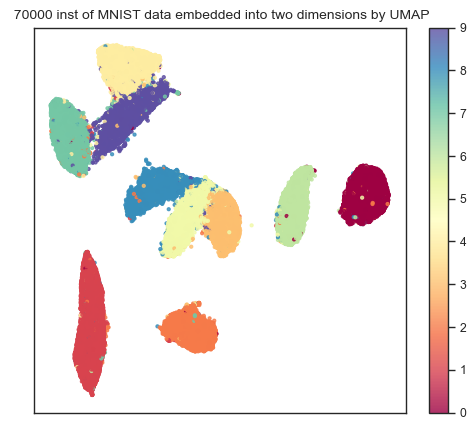

In [72]:
color = mnist.target.astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(embedding2[:, 0], embedding2[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8)
plt.setp(ax, xticks=[], yticks=[])
plt.title(f" {len(embedding2)} inst of MNIST data embedded into two dimensions by UMAP", fontsize=10)
plt.colorbar()
plt.show()

In [ ]:
#variantes: class umap.umap_.UMAP(n_neighbors=15, n_components=2, metric='euclidean', n_epochs=None, learning_rate=1.0, init='spectral', min_dist=0.1, spread=1.0, set_op_mix_ratio=1.0, local_connectivity=1.0, repulsion_strength=1.0, negative_sample_rate=5, transform_queue_size=4.0, a=None, b=None, random_state=None, metric_kwds=None, angular_rp_forest=False, target_n_neighbors=-1, target_metric='categorical', target_metric_kwds=None, target_weight=0.5, transform_seed=42, verbose=False)

#n_neighbours, n_components, metric

## Comparaison avec TSNE

In [32]:
%time embedTSNE = TSNE(n_components=2).fit_transform(mnist.data)

CPU times: user 21min 10s, sys: 6min 7s, total: 27min 18s
Wall time: 3min 8s


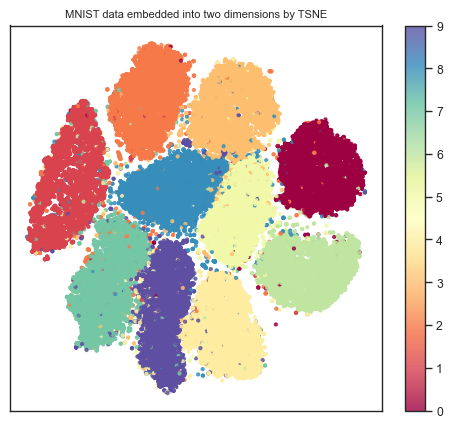

In [35]:
color = mnist.target.astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(embedTSNE[:, 0], embedTSNE[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8)
plt.setp(ax, xticks=[], yticks=[])
plt.title("MNIST data embedded into two dimensions by TSNE", fontsize=8)
plt.colorbar()
plt.show()

In [24]:
# comparaison KNN + selftraining